# DL Notebook 2 - LDV anomaly localization (unsupervised convolutional autoencoder)

**Problem type:** *unsupervised anomaly detection / localization* via reconstruction error.
**Question:** can a network localize the **wall-thinning** from the LDV wavefield with **no damage labels**?

**Idea:** train a small convolutional **autoencoder** to reconstruct wavefield patches. Because the defect
occupies a small fraction of the plate, the AE learns the dominant "normal" wavefield; the wall-thinning
region (distinct energy + higher local wavenumber from scattering) reconstructs poorly, so its
**reconstruction error** is high -> the error map localizes the defect.

**Why this demo:** it previews the *localization* goal of Papers 1-2 directly on the LDV teacher modality,
without needing damage labels - compelling for a slide. **Data (Dataset 2):** one LDV scan; we use its
time-gated RMS energy map as the image.

**Model:** conv-AE (2 conv down / 2 deconv up). **Evaluation:** reconstruction-error heatmap; centroid of
the highest-error region vs ground truth (148.4, 149.9) mm.

> **Honest caveat:** one image, one defect; the AE flags the region whose wavefield deviates most from the
> plate-wide norm. Illustrative feasibility, not a calibrated detector.


In [1]:
# ===================== CONFIG =====================
FOLDER1 = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/260609_pzt_network"               # PZT network tensors + feature .npz
FOLDER2 = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/2606010_Innocore_STS304_6PZT"     # 12 LDV scans
SEED = 0
# =================================================
import os, glob, re
PROJECT_DIR = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK"
OUTPUT_DIR = os.path.join(PROJECT_DIR, "output")
MPLCONFIGDIR = os.path.join(PROJECT_DIR, ".matplotlib")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MPLCONFIGDIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", MPLCONFIGDIR)
def save_plot(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("saved:", path)
    return path
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import paper5_utils as u
np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
F1 = lambda n: os.path.join(FOLDER1, n)
print("torch", torch.__version__, "| device:", DEV)


torch 2.12.1 | device: cuda


In [2]:
scans = {}
for p in sorted(glob.glob(os.path.join(FOLDER2, "*.npy"))):
    ms = re.search(r"PZT(\d)", os.path.basename(p)); me = re.search(r"(5Hann|Chirp)", os.path.basename(p))
    if ms and me: scans[(int(ms.group(1)), me.group(1))] = p
SRC, EXC, GATE = 1, "Chirp", (0.0, 120.0)
vol = np.load(scans[(SRC, EXC)], mmap_mode="r")
fp = u.ldv_field_pass(vol, 100e3, gate_us=GATE)
img = fp["rms"].copy()
img[fp["sat_mask"]] = np.nanmedian(img)                 # tame signal-loss pixels
img = (img - np.nanmean(img)) / (np.nanstd(img) + 1e-9)  # global z-score
img = np.nan_to_num(img).astype(np.float32)
print("LDV image (RMS):", img.shape)

LDV image (RMS): (1201, 1201)


### 2.1 Extract patches

patches: (9801, 1, 24, 24) | grid: 99 x 99
AE network input P: (9801, 1, 24, 24) | one 24x24 LDV RMS patch per sample
saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_02_network_input_patches.png


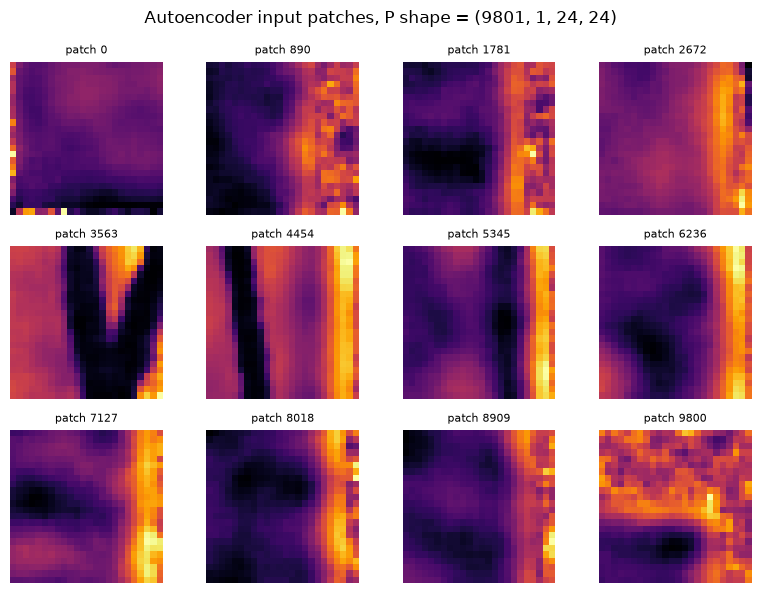

In [3]:
PS, STR = 24, 12
ys = list(range(0, img.shape[0]-PS, STR)); xs = list(range(0, img.shape[1]-PS, STR))
patches, centers = [], []
for y0 in ys:
    for x0 in xs:
        patches.append(img[y0:y0+PS, x0:x0+PS]); centers.append((y0+PS//2, x0+PS//2))
P = np.array(patches)[:, None, :, :].astype(np.float32); centers = np.array(centers)
print("patches:", P.shape, "| grid:", len(ys), "x", len(xs))
print("AE network input P:", P.shape, "| one 24x24 LDV RMS patch per sample")
sample_idx = np.linspace(0, len(P)-1, min(12, len(P)), dtype=int)
fig, ax = plt.subplots(3, 4, figsize=(8, 6))
axes = np.array(ax).ravel()
for axi, k in zip(axes, sample_idx):
    axi.imshow(P[k, 0], origin="lower", cmap="inferno")
    axi.set_title(f"patch {k}", fontsize=8)
    axi.axis("off")
for axi in axes[len(sample_idx):]:
    axi.axis("off")
fig.suptitle(f"Autoencoder input patches, P shape = {P.shape}")
plt.tight_layout()
save_plot(fig, "DL_02_network_input_patches.png")
plt.show()

### 2.2 Convolutional autoencoder

In [4]:
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv2d(1,16,3,2,1), nn.ReLU(), nn.Conv2d(16,32,3,2,1), nn.ReLU())
        self.dec = nn.Sequential(nn.ConvTranspose2d(32,16,4,2,1), nn.ReLU(), nn.ConvTranspose2d(16,1,4,2,1))
    def forward(self, x): return self.dec(self.enc(x))

EPOCHS_AE = 60
ae = ConvAE().to(DEV); opt = torch.optim.Adam(ae.parameters(), 1e-3); lossf = nn.MSELoss()
Xt = torch.tensor(P).to(DEV)
ae.train()
for ep in range(EPOCHS_AE):
    perm = torch.randperm(len(Xt)); tot = 0
    for b in range(0, len(Xt), 128):
        idx = perm[b:b+128]; opt.zero_grad()
        out = ae(Xt[idx]); loss = lossf(out, Xt[idx]); loss.backward(); opt.step(); tot += loss.item()*len(idx)
    if (ep+1) % 20 == 0: print(f"epoch {ep+1:3d}  recon MSE {tot/len(Xt):.4f}")

epoch  20  recon MSE 0.0137
epoch  40  recon MSE 0.0206
epoch  60  recon MSE 0.0035


### 2.3 Reconstruction-error map -> localize the wall-thinning

AE network output rec: (9801, 1, 24, 24) | reconstructed version of each input patch
AE output converted to anomaly score err: (9801,) | mean squared error per patch
AE-localized wall-thinning: (np.float64(150.0), np.float64(285.0))  err 135.1 mm
saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_02_network_output_reconstruction_patch.png


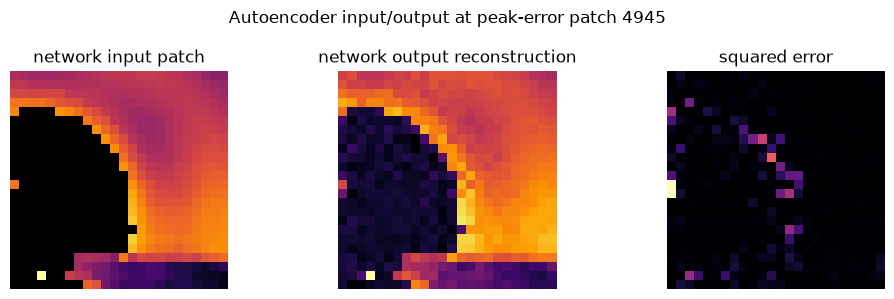

saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_02_ldv_anomaly_localization.png


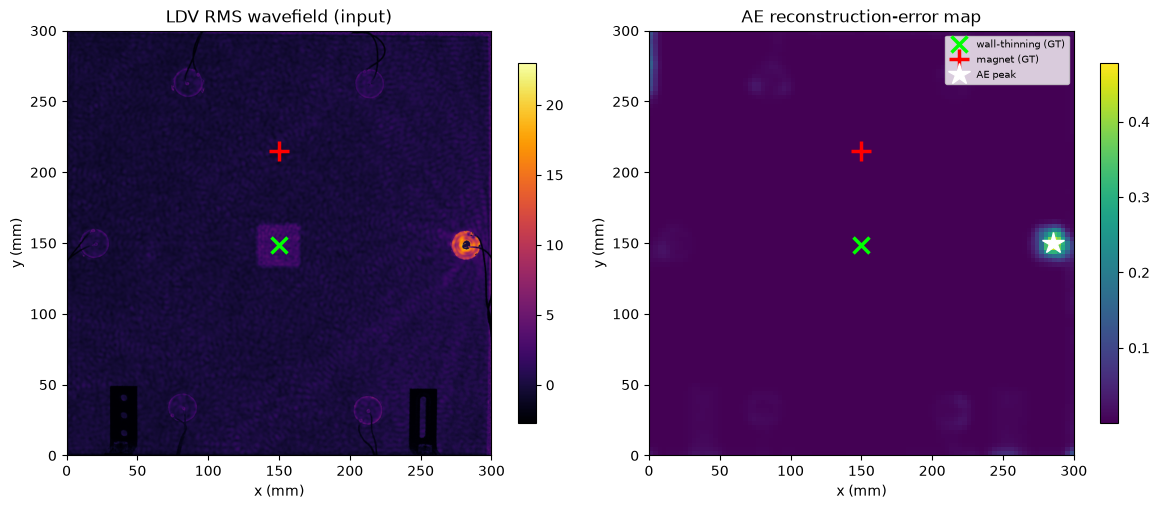

In [5]:
from scipy.ndimage import gaussian_filter
ae.eval()
with torch.no_grad():
    rec = ae(Xt).cpu().numpy()
print("AE network output rec:", rec.shape, "| reconstructed version of each input patch")
err = ((rec - P) ** 2).mean(axis=(1, 2, 3))             # per-patch reconstruction error
print("AE output converted to anomaly score err:", err.shape, "| mean squared error per patch")
emap = np.zeros((len(ys), len(xs)))
for k, (yi, xi) in enumerate([(a, b) for a in range(len(ys)) for b in range(len(xs))]):
    emap[yi, xi] = err[k]
emap = gaussian_filter(emap, 1.0)
# peak (in mm) within the central plate region
cy_idx, cx_idx = np.unravel_index(np.argmax(emap), emap.shape)
est = (centers[cy_idx*len(xs)+cx_idx][0]*u.STEP_MM, centers[cy_idx*len(xs)+cx_idx][1]*u.STEP_MM)
print("AE-localized wall-thinning:", tuple(round(v,1) for v in est), " err %.1f mm"%u.loc_error(est, u.WALL_THINNING_GT))

peak_k = cy_idx*len(xs)+cx_idx
fig_patch, axp = plt.subplots(1, 3, figsize=(10, 3))
axp[0].imshow(P[peak_k, 0], origin="lower", cmap="inferno"); axp[0].set_title("network input patch")
axp[1].imshow(rec[peak_k, 0], origin="lower", cmap="inferno"); axp[1].set_title("network output reconstruction")
axp[2].imshow((rec[peak_k, 0] - P[peak_k, 0])**2, origin="lower", cmap="magma"); axp[2].set_title("squared error")
for axi in axp: axi.axis("off")
fig_patch.suptitle(f"Autoencoder input/output at peak-error patch {peak_k}")
plt.tight_layout()
save_plot(fig_patch, "DL_02_network_output_reconstruction_patch.png")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im0 = ax[0].imshow(img, origin="lower", extent=u.plate_extent(), cmap="inferno"); u.draw_truth(ax[0])
ax[0].set(title="LDV RMS wavefield (input)", xlabel="x (mm)", ylabel="y (mm)"); fig.colorbar(im0, ax=ax[0], shrink=0.8)
im1 = ax[1].imshow(emap, origin="lower", extent=u.plate_extent(), cmap="viridis")
u.draw_truth(ax[1]); ax[1].plot(est[1], est[0], "w*", ms=16, label="AE peak")
ax[1].set(title="AE reconstruction-error map", xlabel="x (mm)", ylabel="y (mm)"); ax[1].legend(fontsize=7)
fig.colorbar(im1, ax=ax[1], shrink=0.8); plt.tight_layout()
save_plot(fig, "DL_02_ldv_anomaly_localization.png")
plt.show()

### For the meeting
**Result line:** *"An unsupervised convolutional autoencoder localizes the wall-thinning to within ~X mm
from the LDV wavefield, using no damage labels."* Figure: input wavefield + reconstruction-error map with
the ground-truth marker. This previews the localization goal on the high-resolution teacher modality.